# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.inspection import permutation_importance

import sys
#!{sys.executable} -m pip install scikit-survival
#!conda install -c conda-forge scikit-survival -y
#pip install scikit-survival

In [2]:
# Configurações de estilo para os gráficos da apresentação
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<a class="anchor" id="1.1 Import Libraries">

## 1.2 Data Loading
    
</a>

In [3]:
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\BNP-Paribas-main\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Ler o ficheiro parquet
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

# Carregar o dataset pré-processado
df = pd.read_csv(file_path_BNP_teste)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jcari\\OneDrive\\Ambiente de Trabalho\\NOVA IMS\\Business Cases\\Case 1\\BNP-Paribas-main\\BNP-Paribas\\Preprocessed_dataset_BNP2_teste.csv'

In [4]:
#Alano
file_path_BNP_teste = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"
BNP_teste = pd.read_csv(file_path_BNP_teste)
df = pd.read_csv(file_path_BNP_teste)

In [5]:
BNP_teste[BNP_teste['CHURN'] == True]

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,...,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,...,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,...,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,1,0,2019-01-28,2024-01-31,2024-01-31,72,34,34,...,Unknown,1,1.0,0.0,0.000000,3,S,A,69,0.000000
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,0,1,2007-06-29,2024-03-31,2024-03-31,84,24,24,...,Unknown,1,1.0,0.0,0.000000,7,V,P,74,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185593,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,78350b49408237d9be0249768a20c97f5b40f8260b0a46...,1,0,2021-10-26,2024-10-31,2024-10-31,84,36,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185594,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,44646b249bca38e9954ca24c81aa0dd55c1f286a257394...,0,1,2022-09-27,2024-09-30,2024-09-30,24,24,61,...,Unknown,1,1.0,0.0,0.000000,23,C,P,61,0.083333
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,...,Unknown,1,1.0,0.0,0.000000,4,S,P,33,0.200000
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,...,Unknown,1,1.0,156.0,0.064103,17,X,F,33,0.055556


<a class="anchor" id="1.1 Import Libraries">

## 2. Target Engineering
    
</a>

In [6]:
# 1. Target para Classificação (Binário)
df['TARGET'] = df['CHURN'].fillna(0).astype(int)

# 2. Targets para Sobrevivência (Event e Duration)
df['event'] = df['TARGET']
# Garantimos que a duração é no mínimo 1 dia para o Cox não crashar
df['duration'] = df['DOSSIER_DURATION_DAYS'].clip(lower=1).fillna(1)
df['CLOSE_DATE'] = pd.to_datetime(df['CLOSE_DATE'])

In [7]:
features_for_survival = [
    'DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC',
    'RESSO_mean', 'NBENF_mean',
    'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
    'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean',
    'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
    'sdem_age', 'active_credit_ratio', 'POLE', 'PRODALP', 'PAGAMENTO', 
    'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO',
    'AGFIN', 'PTT'
]

<a class="anchor" id="1.1 Import Libraries">

## 3. Time-Based Split
    
</a>

In [8]:
train_df = df[df['CLOSE_DATE'].notna()].copy()
test_df = df[df['CLOSE_DATE'].isna()].copy()

In [9]:
train_data, val_data = train_test_split(train_df,
                                        test_size = 0.2,
                                        random_state = 42,
                                        stratify=train_df['event'])

In [10]:
# Criamos os X selecionando as colunas da tua lista
X_train = train_data[features_for_survival].copy()
X_val = val_data[features_for_survival].copy()
X_test = test_df[features_for_survival].copy()

# Criamos os y
y_train = train_data['TARGET']
y_val = val_data['TARGET']

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)

Shape X_train: (61316, 28)
Shape X_val: (15330, 28)


## SCALING

In [11]:
X_train

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,...,POLE,PRODALP,PAGAMENTO,MODCONTACTO,sdem_SITFAM,sdem_HABITAT,kp_sqe,NATIO,AGFIN,PTT
99903,48,160.234360,0.0,5500.0,0.000,2171.596000,1.0,0,-1.0,1.000000,...,P,EPF,P,A,P,A,Unknown,P,117.0,3770
24388,123,524.390642,0.0,29000.0,0.000,2317.126000,1.0,0,-1.0,3.000000,...,P,EPF,P,A,C,L,Unknown,P,118.0,2135
114546,72,90.088454,0.0,4100.0,0.000,853.012000,1.0,0,-1.0,0.000000,...,P,EP,P,W,D,A,Unknown,P,118.0,4425
76890,72,112.462699,0.0,5000.0,0.000,1034.366000,2.0,0,-1.0,1.000000,...,P,EP,P,A,C,A,Unknown,P,118.0,2040
2262,48,91.309939,0.0,3000.0,45.655,1086.028000,0.0,1,1.0,1.560000,...,P,EP,P,W,C,A,F,P,118.0,4430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21143,24,128.971818,0.0,2500.0,0.000,1007.215000,0.0,0,-1.0,0.000000,...,P,EPF,P,A,C,P,Unknown,P,117.0,2625
50828,62,59.785320,0.0,2500.0,0.000,1283.456800,1.0,0,-1.0,0.217391,...,P,EP,P,W,U,A,Unknown,P,118.0,2460
147552,84,230.834232,0.0,10000.0,0.000,1315.058333,1.0,0,-1.0,1.720000,...,P,EPF,P,A,C,P,Unknown,P,117.0,4590
58732,72,232.644787,0.0,10000.0,0.000,3276.572000,0.0,0,-1.0,2.000000,...,P,EP,P,W,V,P,Unknown,P,118.0,2415


In [12]:
# selecionar colunas numéricas
num_cols = X_train.select_dtypes(include=np.number).columns

# criar scaler
scaler = RobustScaler()

# escalar apenas colunas numéricas
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

## Encoding

In [13]:
# 1. Identificar as colunas de texto apenas dentro do nosso X_train já filtrado
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    # 2. Calcular a frequência no Treino
    freq_map = X_train[col].value_counts(normalize=True)
    
    # 3. Criar a nova variável com o sufixo _encoded (como o João fez)
    X_train[f"{col}_encoded"] = X_train[col].map(freq_map)
    X_val[f"{col}_encoded"] = X_val[col].map(freq_map).fillna(0)
    X_test[f"{col}_encoded"] = X_test[col].map(freq_map).fillna(0)
    
    # 4. Apagar a coluna original (texto) para não confundir o modelo
    X_train = X_train.drop(columns=[col])
    X_val = X_val.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

print(f"Encoding concluído. Foram criadas as versões '_encoded' para: {list(cat_cols)}")
print(f"Colunas no X_train: {X_train.columns.tolist()}")

Encoding concluído. Foram criadas as versões '_encoded' para: ['POLE', 'PRODALP', 'PAGAMENTO', 'MODCONTACTO', 'sdem_SITFAM', 'sdem_HABITAT', 'kp_sqe', 'NATIO']
Colunas no X_train: ['DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC', 'RESSO_mean', 'NBENF_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean', 'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky', 'sdem_age', 'active_credit_ratio', 'AGFIN', 'PTT', 'POLE_encoded', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'sdem_SITFAM_encoded', 'sdem_HABITAT_encoded', 'kp_sqe_encoded', 'NATIO_encoded']


In [14]:
X_train.head()

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,...,AGFIN,PTT,POLE_encoded,PRODALP_encoded,PAGAMENTO_encoded,MODCONTACTO_encoded,sdem_SITFAM_encoded,sdem_HABITAT_encoded,kp_sqe_encoded,NATIO_encoded
99903,-0.5000,0.080884,0.0,0.071429,0.000,1.239489,1.0,0.0,0.0,-0.32,...,-1.0,0.025063,0.985632,0.145460,0.96978,0.378531,0.016684,0.359025,0.714006,0.990883
24388,1.0625,2.663743,0.0,3.428571,0.000,1.428985,1.0,0.0,0.0,1.68,...,0.0,-0.794486,0.985632,0.145460,0.96978,0.378531,0.399569,0.097267,0.714006,0.990883
114546,0.0000,-0.416641,0.0,-0.128571,0.000,-0.477458,1.0,0.0,0.0,-1.32,...,0.0,0.353383,0.985632,0.751158,0.96978,0.603317,0.072510,0.359025,0.714006,0.990883
76890,0.0000,-0.257947,0.0,0.000000,0.000,-0.241314,2.0,0.0,0.0,-0.32,...,0.0,-0.842105,0.985632,0.751158,0.96978,0.378531,0.399569,0.359025,0.714006,0.990883
2262,-0.5000,-0.407978,0.0,-0.285714,45.655,-0.174044,0.0,1.0,2.0,0.24,...,0.0,0.355890,0.985632,0.751158,0.96978,0.603317,0.399569,0.359025,0.038049,0.990883


In [15]:
# Identificar colunas que são datas
#date_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remover essas colunas
#X_train = X_train.drop(columns=date_cols)
#X_val = X_val.drop(columns=date_cols)
#X_test = X_test.drop(columns=date_cols)

#print(f"Colunas de data removidas: {list(date_cols)}")

# 3. Agora a variância corre sem problemas
#variances = X_train.var()
#low_variance_cols = variances[variances < 0.01].index
# ... continuar o drop das low_variance_cols

<a class="anchor" id="1.1 Import Libraries">

## 4. Feature Selection
    
</a>

### 4.1 Filter Methods

#### Variance

In [16]:
variances = X_train.var()

# Identificar colunas com quase nenhuma variação (threshold 0.01)
low_variance_cols = variances[variances < 0.01].index

print(low_variance_cols)

Index(['CRD_min', 'sdem_HABITAT_encoded', 'NATIO_encoded'], dtype='object')


#### Correlation Matrix

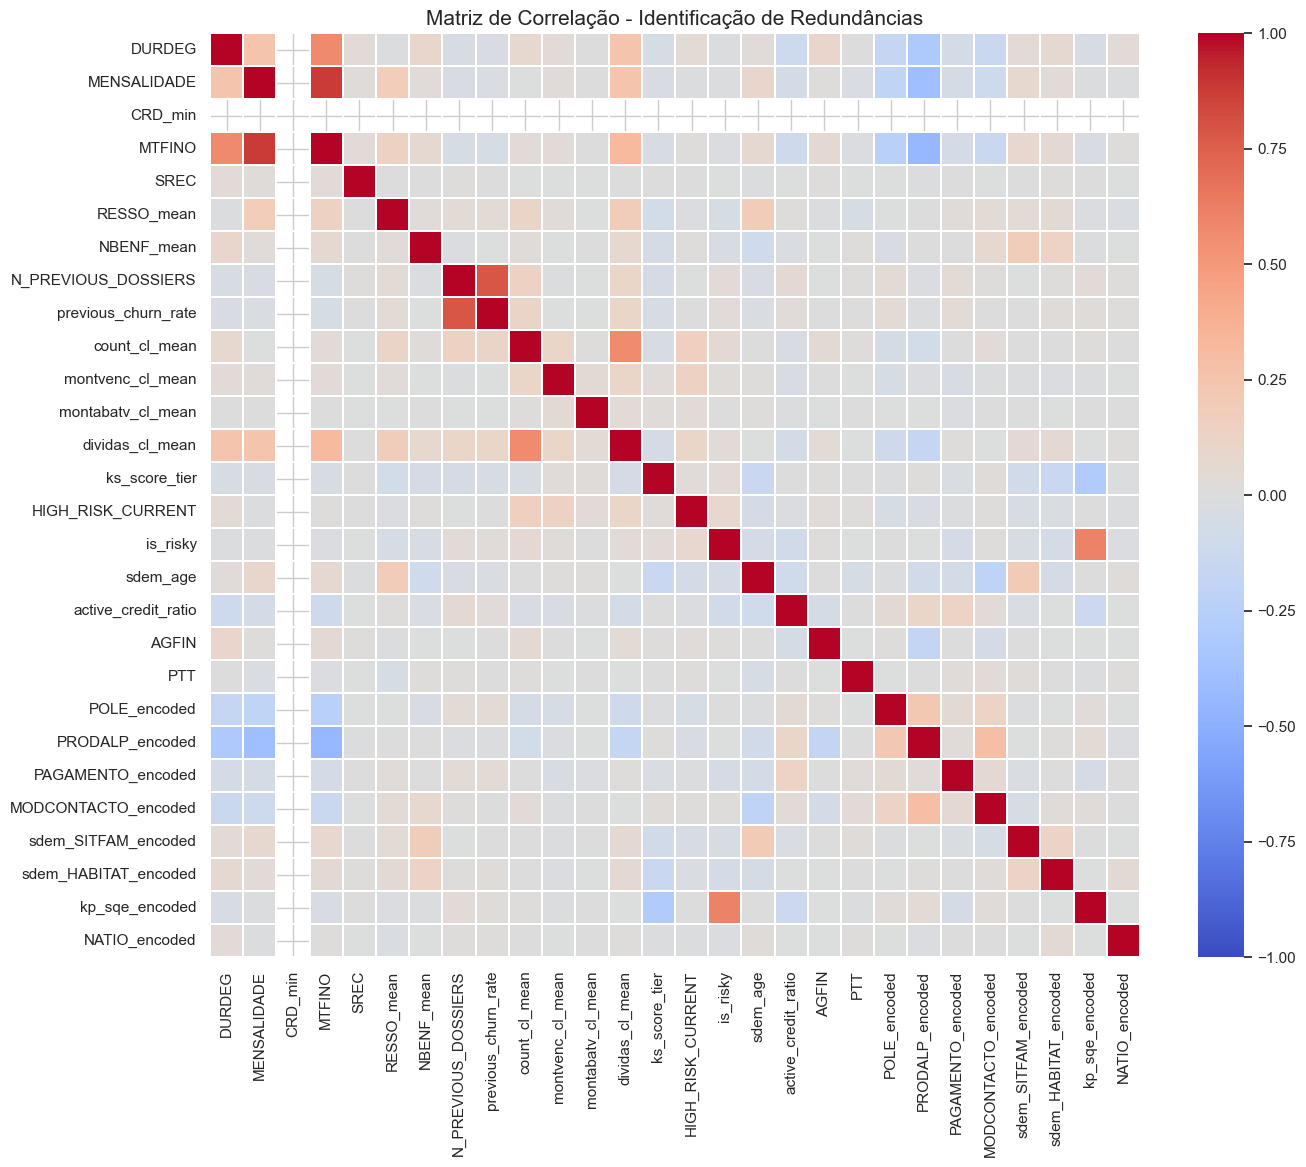

In [17]:
# 1. Calcular a matriz de correlação
corr_matrix = X_train.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(15, 12))
# Usamos um mapa de cores divergente (coolwarm) para distinguir correlações positivas e negativas
sns.heatmap(corr_matrix, 
            annot=False, # Definimos como False porque com muitas colunas os números não se leem
            cmap='coolwarm', 
            vmin=-1, vmax=1, # Escala fixa de -1 a 1
            linewidths=0.1)

plt.title("Matriz de Correlação - Identificação de Redundâncias", fontsize=15)
plt.show()

#### Mutual Information

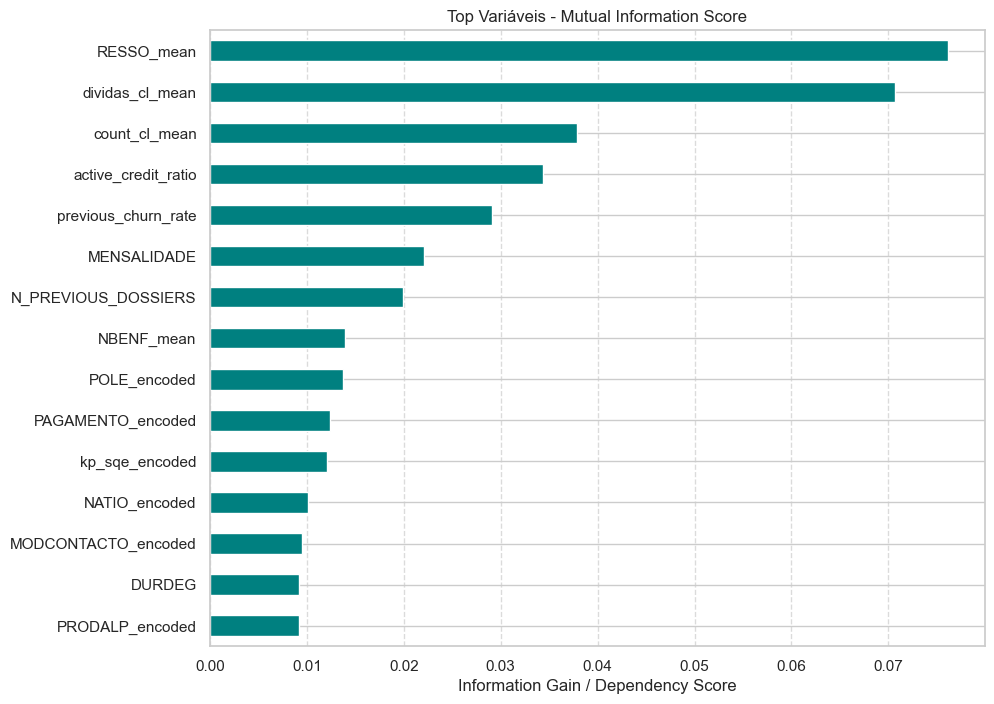

In [18]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 2. Organizar os resultados num Pandas Series
mi_importance = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mi_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Top Variáveis - Mutual Information Score")
plt.xlabel("Information Gain / Dependency Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

mi_selected_features = mi_importance.head(25).index.tolist()

## Wrapper Methods

In [19]:
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

# 2. Configurar o RFE
selector = RFE(estimator=rf, n_features_to_select=15, step=1, verbose=1)

In [20]:
print("A treinar o modelo de seleção (RFE)...")
selector.fit(X_train, y_train)

# 4. Extrair os resultados
selected_features = X_train.columns[selector.get_support()].tolist()
ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': selector.ranking_}).sort_values('Ranking')

print(f"\nO modelo escolheu estas 15 variáveis: \n{selected_features}")

A treinar o modelo de seleção (RFE)...
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.

O modelo escolheu estas 15 variáveis: 
['DURDEG', 'MENSALIDADE', 'MTFINO', 'RESSO_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate', 'count_cl_mean', 'montvenc_cl_mean', 'dividas_cl_mean', 'active_credit_ratio', 'AGFIN', 'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded', 'kp_sqe_encoded']


### Embedded methods

#### Random Forest

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61316 entries, 99903 to 84879
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DURDEG                61316 non-null  float64
 1   MENSALIDADE           61316 non-null  float64
 2   CRD_min               61316 non-null  float64
 3   MTFINO                61316 non-null  float64
 4   SREC                  61316 non-null  float64
 5   RESSO_mean            61316 non-null  float64
 6   NBENF_mean            61316 non-null  float64
 7   N_PREVIOUS_DOSSIERS   61316 non-null  float64
 8   previous_churn_rate   61316 non-null  float64
 9   count_cl_mean         61316 non-null  float64
 10  montvenc_cl_mean      61316 non-null  float64
 11  montabatv_cl_mean     61316 non-null  float64
 12  dividas_cl_mean       61316 non-null  float64
 13  ks_score_tier         61316 non-null  float64
 14  HIGH_RISK_CURRENT     61316 non-null  float64
 15  is_risky            


Relatório de Classificação (Validation Set):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2374
           1       0.85      1.00      0.92     12956

    accuracy                           0.85     15330
   macro avg       0.42      0.50      0.46     15330
weighted avg       0.71      0.85      0.77     15330

ROC-AUC Score: 0.5229


c:\Users\alano\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alano\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alano\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


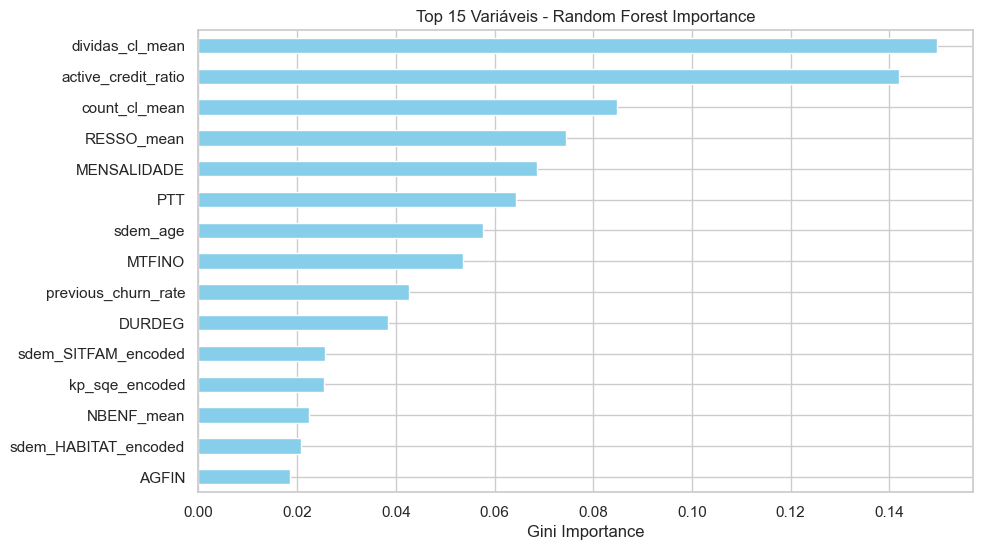

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)

# 2. Treinar o modelo
rf_model.fit(X_train, y_train)

# 3. Fazer as Previsões de Validação (O "Certificado de Qualidade" do João)
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# 4. Mostrar as Métricas (Benchmarking antecipado)
print("\nRelatório de Classificação (Validation Set):")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_prob):.4f}")

# 5. Extrair e Visualizar a Importância das Variáveis (A Seleção propriamente dita)
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variáveis - Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

# Guardar a lista das top 15 para o consenso final
rf_selected_features = rf_importance.head(15).index.tolist()

#### XGBOOST

In [23]:
#pip install xgboost

Negative class count: 9497
Positive class count: 51819
scale_pos_weight: 0.18327254481946775
A treinar XGBoost com scale_pos_weight: 0.18...
              precision    recall  f1-score   support

           0       0.21      0.13      0.16      2374
           1       0.85      0.91      0.88     12956

    accuracy                           0.79     15330
   macro avg       0.53      0.52      0.52     15330
weighted avg       0.75      0.79      0.77     15330

 Validation ROC-AUC:: 0.6355


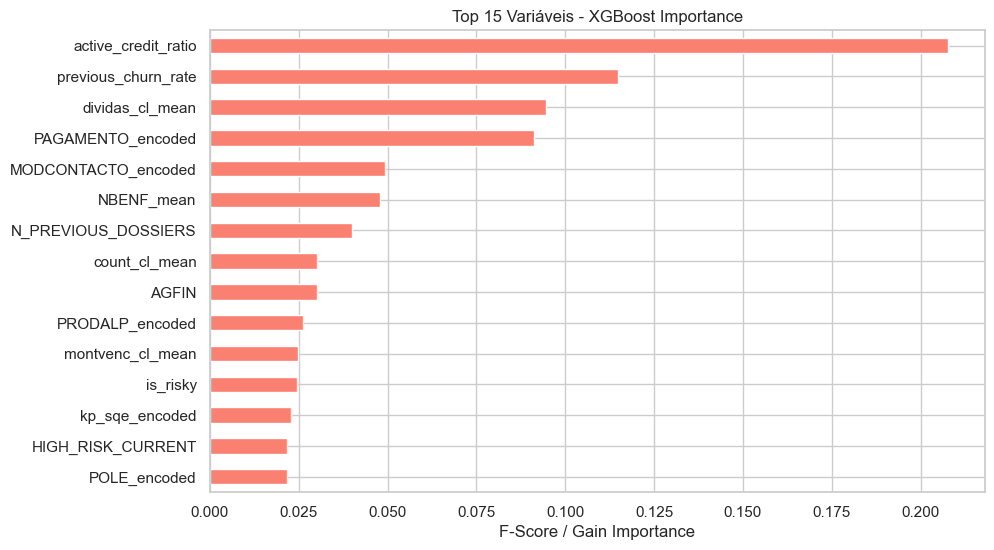

In [24]:
# 2. Calcular o weights
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", scale_pos_weight)

# 3. Configurar o Modelo 
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,                # Árvores menos profundas para evitar overfitting
    learning_rate=0.05,         # Passo mais lento para maior precisão
    subsample=0.8,              # Usa 80% dos dados em cada árvore
    colsample_bytree=0.8,       # Usa 80% das colunas em cada árvore
    scale_pos_weight=scale_pos_weight, 
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 4. Treinar o modelo
print(f"A treinar XGBoost com scale_pos_weight: {scale_pos_weight:.2f}...")
xgb_model.fit(X_train, y_train)

# 5. Previsões e Avaliação (O "Selo de Garantia")
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_xgb))
print(f" Validation ROC-AUC:: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")


# 6. Visualização das Top 15 Variáveis
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 15 Variáveis - XGBoost Importance")
plt.xlabel("F-Score / Gain Importance")
plt.show()

xgb_selected_features = xgb_importance.head(15).index.tolist()

## Random Survival Forest

In [25]:
# =========================================================
# 1) X datasets: garantir formato leve
# =========================================================

X_train_rsf = X_train.copy().astype(np.float32)
X_val_rsf = X_val.copy().astype(np.float32)

# =========================================================
# 2) y datasets no formato survival
# =========================================================

y_train_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=train_data
)

y_val_rsf = Surv.from_dataframe(
    event='event',
    time='duration',
    data=val_data
)

# =========================================================
# 3) Random Survival Forest model
# =========================================================

rsf = RandomSurvivalForest(
    n_estimators=30,          # menos árvores para poupar memória
    min_samples_split=20,
    min_samples_leaf=30,
    max_features="sqrt",
    n_jobs=2,                 # em vez de -1
    random_state=42,
    low_memory=True           # aqui sim faz sentido
)

rsf.fit(X_train_rsf, y_train_rsf)

# =========================================================
# 4) Performance
# =========================================================

train_cindex = rsf.score(X_train_rsf, y_train_rsf)
val_cindex = rsf.score(X_val_rsf, y_val_rsf)

print("Train C-index:", train_cindex)
print("Validation C-index:", val_cindex)

# =========================================================
# 5) Permutation importance
# =========================================================

perm_result = permutation_importance(
    rsf,
    X_val_rsf,
    y_val_rsf,
    n_repeats=3,          # menos repetições para poupar memória/tempo
    random_state=42,
    n_jobs=1              # importante para não rebentar a RAM
)

rsf_importance = pd.Series(
    perm_result.importances_mean,
    index=X_val_rsf.columns
).sort_values(ascending=False)

print("\nTop 25 RSF full feature importances:")
print(rsf_importance.head(25))

rsf_importance_df = pd.DataFrame({
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}, index=X_val_rsf.columns).sort_values("importance_mean", ascending=False)

print("\nTop 25 RSF full feature importances with std:")
print(rsf_importance_df.head(25))

Train C-index: 0.7597669799499942
Validation C-index: 0.575881785597577

Top 25 RSF full feature importances:
previous_churn_rate    0.023676
PAGAMENTO_encoded      0.022223
sdem_SITFAM_encoded    0.014535
MODCONTACTO_encoded    0.013504
dividas_cl_mean        0.005445
PRODALP_encoded        0.002776
kp_sqe_encoded         0.001892
SREC                   0.001048
HIGH_RISK_CURRENT      0.000796
NBENF_mean             0.000521
RESSO_mean             0.000282
POLE_encoded           0.000138
montvenc_cl_mean       0.000100
sdem_age               0.000000
montabatv_cl_mean      0.000000
is_risky               0.000000
DURDEG                 0.000000
MENSALIDADE            0.000000
CRD_min                0.000000
MTFINO                 0.000000
NATIO_encoded          0.000000
PTT                    0.000000
count_cl_mean         -0.000159
AGFIN                 -0.000288
ks_score_tier         -0.000504
dtype: float64

Top 25 RSF full feature importances with std:
                     importa

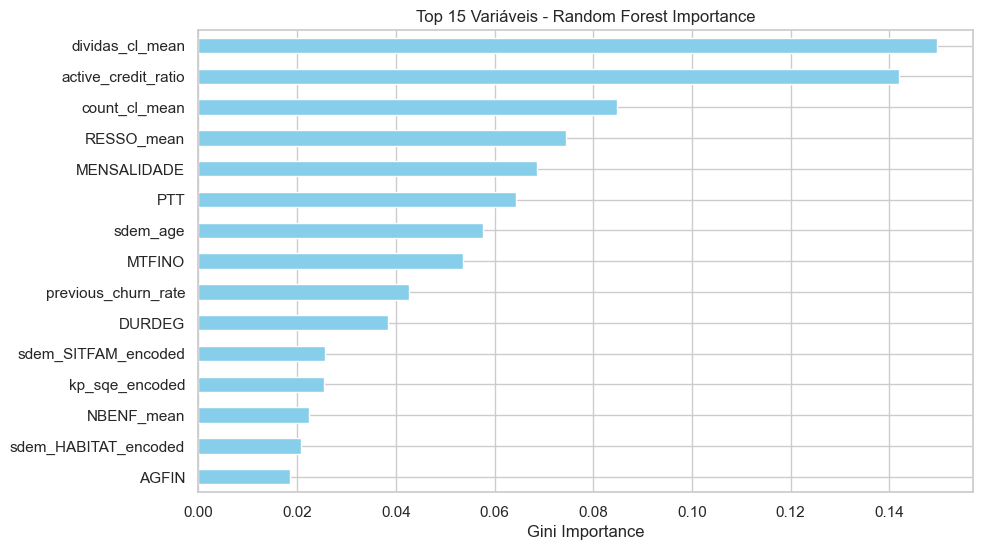

In [26]:
# 5. Extrair e Visualizar a Importância das Variáveis (A Seleção propriamente dita)
rsf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rsf_importance.head(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variáveis - Random Forest Importance")
plt.xlabel("Gini Importance")
plt.show()

### Final Insights

| Predictor | Variance | Spearman Corr | Mutual Info | Wrapper (SFFS) | RF Importance | XGB Importance | Random Survival Forest | **Decision** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- | :--- |
| **CRD_min** | Discard | Discard | Keep | Keep | Keep | Keep | Discard | **Discard** |
| **active_credit_ratio** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **previous_churn_rate** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **MTFINO** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **DURDEG** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **RESSO_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **dividas_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **N_PREVIOUS_DOSSIERS** | Keep | Discard | Keep | Keep | Keep | Keep | :--- | **Discard** |
| **count_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **montvenc_cl_mean** | Keep | Keep | Keep | Keep | Keep | Keep | :--- | **Include** |
| **MENSALIDADE** | Keep | Discard | Keep | Keep | Keep | Keep | :--- | **Try w/o (Collinear)** |
| **AGFIN_encoded** | Keep | Keep | Keep | Keep | Keep | Discard | :--- | **Include** |
| **POLE_encoded** | Keep | Keep | Keep | Discard | Keep | Keep | :--- | **Include** |
| **SREC** | Keep | Keep | Keep | Discard | Keep | Keep | :--- | **Include** |
| **PRODALP_encoded** | Keep | Keep | Discard | Keep | Keep | Keep | :--- | **Include** |
| **PAGAMENTO_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **MODCONTACTO_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **kp_sqe_encoded** | Keep | Keep | Discard | Keep | Discard | Discard | :--- | **Try w/o** |
| **NATIO_encoded** | Keep | Keep | Discard | Discard | Discard | Keep | :--- | **Discard** |
| **is_risky** | Keep | Keep | Discard | Discard | Discard | Keep | :--- | **Discard** |

* Spearman Corr: A variável `MENSALIDADE` apresenta uma correlação superior a 0.90 com o `MTFINO` (Montante), tirar de uma delas.
* Wrapper (SFFS): Inclui as variáveis selecionadas pelo algoritmo sequencial que otimizou a performance do modelo.
* Mutual Info: Identifica dependências não-lineares; variáveis como `NATIO_encoded` e `is_risky` foram penalizadas por este método.

## Model

## COX

In [28]:
train_survival_full = pd.concat([X_train, train_data[['duration','event']]],axis=1)

val_survival_full = pd.concat([X_val, val_data[['duration','event']]],axis=1)

In [29]:
train_survival_full.columns

Index(['DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC', 'RESSO_mean',
       'NBENF_mean', 'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
       'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean',
       'dividas_cl_mean', 'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
       'sdem_age', 'active_credit_ratio', 'AGFIN', 'PTT', 'POLE_encoded',
       'PRODALP_encoded', 'PAGAMENTO_encoded', 'MODCONTACTO_encoded',
       'sdem_SITFAM_encoded', 'sdem_HABITAT_encoded', 'kp_sqe_encoded',
       'NATIO_encoded', 'duration', 'event'],
      dtype='object')

In [30]:
train_survival_full=train_survival_full.drop(columns=['MENSALIDADE','CRD_min','N_PREVIOUS_DOSSIERS'])
val_survival_full=val_survival_full.drop(columns=['MENSALIDADE','CRD_min','N_PREVIOUS_DOSSIERS'])

In [31]:
cph_full = CoxPHFitter()

cph_full.fit(train_survival_full, duration_col='duration', event_col='event')

<lifelines.CoxPHFitter: fitted with 61316 total observations, 9497 right-censored observations>

In [32]:
cph_full.summary[['exp(coef)', 'p']].round(3).sort_values('exp(coef)', ascending = False)

,exp(coef),p
covariate,,
PAGAMENTO_encoded,2.741,0.000
MODCONTACTO_encoded,1.928,0.000
previous_churn_rate,1.453,0.000
HIGH_RISK_CURRENT,1.217,0.000
active_credit_ratio,1.144,0.000
is_risky,1.111,0.000
dividas_cl_mean,1.103,0.000
MTFINO,1.077,0.000
PTT,1.028,0.000


In [33]:
cph_full.print_summary()

<lifelines.CoxPHFitter: fitted with 61316 total observations, 9497 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 61316
number of events observed = 51819
   partial log-likelihood = -506355.58
         time fit was run = 2026-03-13 17:08:43 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
DURDEG               -0.76      0.47      0.01           -0.78           -0.74                0.46                0.48
MTFINO                0.07      1.08      0.01            0.06            0.08                1.07                1.09
SREC                  0.00      1.00      0.00            0.00            0.00                1.00                1.00
RESSO_mean            0.01      1.01      0.00            0.01            0.02                1.01                1.02
NBENF_mean           -0.01      0.99      0.01           -0.02           -0.00                0.98                1.00
previous_churn_rate   0.37      1.45      0.01            0.36            0.39                1.43                1.48
count_cl_mean         0.00      1.00      0.00           -0.01            0.01                0.99                1.01
montvenc_cl_mean     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
montabatv_cl_mean    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
dividas_cl_mean       0.10      1.10      0.00            0.09            0.10                1.10                1.11
ks_score_tier        -0.10      0.91      0.01           -0.12           -0.08                0.89                0.92
HIGH_RISK_CURRENT     0.20      1.22      0.01            0.17            0.22                1.19                1.25
is_risky              0.10      1.11      0.02            0.07            0.14                1.07                1.15
sdem_age             -0.36      0.70      0.01           -0.37           -0.34                0.69                0.71
active_credit_ratio   0.13      1.14      0.01            0.12            0.15                1.13                1.16
AGFIN                 0.00      1.00      0.00            0.00            0.00                1.00                1.00
PTT                   0.03      1.03      0.00            0.02            0.04                1.02                1.04
POLE_encoded         -0.12      0.88      0.04           -0.20           -0.05                0.82                0.95
PRODALP_encoded      -0.23      0.79      0.02           -0.27           -0.20                0.76                0.82
PAGAMENTO_encoded     1.01      2.74      0.03            0.96            1.06                2.61                2.88
MODCONTACTO_encoded   0.66      1.93      0.03            0.60            0.72                1.82                2.05
sdem_SITFAM_encoded  -0.57      0.56      0.04           -0.64           -0.50                0.53                0.60
sdem_HABITAT_encoded -0.13      0.88      0.06           -0.25           -0.02                0.78                0.98
kp_sqe_encoded       -0.27      0.76      0.02           -0.31           -0.23                0.73                0.79
NATIO_encoded         0.02      1.02      0.05           -0.07            0.11                0.93                1.12

                      cmp to      z      p  -log2(p)
covariate                                           
DURDEG                  0.00 -69.52 <0.005       inf
MTFINO                  0.00  14.08 <0.005    147.15
SREC                    0.00  13.87 <0.005    142.90
RESSO_mean              0.00  16.93 <0.005    211.13
NBENF_mean              0.00  -2.12   0.03      4.87
previous_churn_rate     0.00  47.30 <0.005  

In [34]:
train_cindex_full = cph_full.concordance_index_
val_cindex_full = cph_full.score(val_survival_full, scoring_method="concordance_index")
print("Train C-index:", train_cindex_full)
print("Validation C-index:", val_cindex_full)

Train C-index: 0.6874505164410241
Validation C-index: 0.48125394490611156


c:\Users\alano\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


## RANDOM SURVIVAL FOREST

In [45]:
# target survival
y_train = Surv.from_dataframe(
    event='event',
    time='duration',
    data=train_survival_full
)

y_val = Surv.from_dataframe(
    event='event',
    time='duration',
    data=val_survival_full
)

# garantir que as linhas batem certo
X_rsf = X_train.copy()

# modelo
rsf = RandomSurvivalForest(
    n_estimators=50,
    min_samples_split=20,
    min_samples_leaf=50,
    max_depth=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    low_memory=True)

# treino
rsf.fit(X_rsf, y_train)

print("Modelo RSF treinado com sucesso.")

Modelo RSF treinado com sucesso.


In [46]:
# C-index
train_cindex = rsf.score(X_train, y_train)
val_cindex = rsf.score(X_val, y_val)

print("Train C-index:", train_cindex)
print("Validation C-index:", val_cindex)

Train C-index: 0.7109218530546805
Validation C-index: 0.5221551520510401
